## Workbook containing the proposed figures for chapter 1 

Table reporting of streamflow performance (NSE and KGE quartiles broken down by glaciation)

In [9]:
import numpy as np
import pandas as pd
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, TEST_START_YEAR, TEST_END_YEAR

ENSEMBLE_MEMBERS = 10
model_list = ['area', 'baseline', 'topographic', 'phase-split']

# define the evaluation metrics (NSE, KGE, and PBIAS), robust to missing values (NaNs)
def nse(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    sim_masked = sim[mask]
    denom = np.sum((obs_masked - np.mean(obs_masked)) ** 2)
    if denom == 0: return np.nan
    return 1 - np.sum((obs_masked - sim_masked) ** 2) / denom

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def pbias(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask): return np.nan
    obs_masked = obs[mask]
    denom = np.sum(obs_masked)
    if denom == 0: return np.nan
    return 100 * np.sum(sim[mask] - obs_masked) / denom

# load the ground truth data
static_atts = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0)
streamflow = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col=0)

# Convert the ground truth streamflow data to units of mm/day
streamflow.index = pd.to_datetime(streamflow.index)
test_years_mask = (streamflow.index.year >= TEST_START_YEAR) & (streamflow.index.year <= TEST_END_YEAR)
streamflow_test = streamflow.loc[test_years_mask]

# Align the static attributes order exactly with the streamflow columns
common_columns = streamflow_test.columns.intersection(static_atts.index)
streamflow_test = streamflow_test[common_columns]
areas = static_atts.loc[common_columns, 'basin_area_km2']

# Vectorized operation across all 290 columns at once
# (m3/s) / (km2 * 1e6) * 86400 s/day * 1000 mm/m -> mm/day
conversion_factor = 86400 * 1e3 / (areas * 1e6)
streamflow_mm = streamflow_test.multiply(conversion_factor, axis=1)

# Identify glaciated stations
glacier_col = [c for c in static_atts.columns if 'glacier_pct' in c.lower()][0]
glaciated_stations = static_atts[static_atts[glacier_col] > 0].index.intersection(streamflow_mm.columns)
all_stations = streamflow_mm.columns

# Container for final report records
summary_records = []

for model in model_list:
    # Storage arrays for metrics per member per station
    # Shape: (Ensemble_Members, Stations)
    member_kge_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_nse_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    member_pbias_all = np.zeros((ENSEMBLE_MEMBERS, len(all_stations)))
    
    # Track ensemble mean time-series prediction per station
    ens_mean_preds = pd.DataFrame(0.0, index=streamflow_mm.index, columns=all_stations)
    
    # 1. First Pass: Load all member predictions, calculate individual metrics, and build ensemble mean
    for i in range(ENSEMBLE_MEMBERS):
        file_fact = OUTPUT_DATA_DIR / model / f"{model}_preds_member_{i}.csv"
        # Assuming predictions columns match station IDs and rows match the date index
        preds = pd.read_csv(file_fact, index_col=0)
        preds.index = pd.to_datetime(preds.index)
        preds = preds.loc[streamflow_mm.index, all_stations] # Align perfectly
        
        ens_mean_preds += preds / ENSEMBLE_MEMBERS
        
        for s_idx, station in enumerate(all_stations):
            obs_series = streamflow_mm[station].values
            sim_series = preds[station].values
            member_kge_all[i, s_idx] = kge(obs_series, sim_series)
            member_nse_all[i, s_idx] = nse(obs_series, sim_series)
            member_pbias_all[i, s_idx] = pbias(obs_series, sim_series)

    # 2. Compute metrics for the actual Ensemble Mean time series
    ens_mean_kge_all = np.array([kge(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_nse_all = np.array([nse(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])
    ens_mean_pbias_all = np.array([pbias(streamflow_mm[st].values, ens_mean_preds[st].values) for st in all_stations])

    # 3. Aggregate metrics over spatial subsets (All vs. Glaciated)
    for subset_name, subset_stations in [("All Basins", all_stations), ("Glaciated Basins", glaciated_stations)]:
        # Get positional indices of subset stations relative to the 'all_stations' list
        sub_indices = [all_stations.get_loc(st) for st in subset_stations]
        
        # Individual member spatial aggregations
        sub_member_kge = np.nanmedian(member_kge_all[:, sub_indices], axis=1)
        sub_member_nse = np.nanmedian(member_nse_all[:, sub_indices], axis=1)
        sub_member_pbias = np.nanmedian(member_pbias_all[:, sub_indices], axis=1)
        
        sub_member_kge_gt07 = np.sum(member_kge_all[:, sub_indices] > 0.7, axis=1)
        sub_member_kge_lt0 = np.sum(member_kge_all[:, sub_indices] < 0.0, axis=1)
        
        # Ensemble mean spatial aggregations
        ens_mean_kge_med = np.nanmedian(ens_mean_kge_all[sub_indices])
        ens_mean_nse_med = np.nanmedian(ens_mean_nse_all[sub_indices])
        ens_mean_pbias_med = np.nanmedian(ens_mean_pbias_all[sub_indices])
        ens_mean_kge_gt07 = np.sum(ens_mean_kge_all[sub_indices] > 0.7)
        ens_mean_kge_lt0 = np.sum(ens_mean_kge_all[sub_indices] < 0.0)
        
        # Format strings as: Single Member Mean ± Std [Ensemble Mean Prediction value]
        def format_stat(member_arr, mean_val, is_int=False):
            fmt = "{:.0f}" if is_int else "{:.3f}"
            return f"{fmt.format(np.mean(member_arr))} ± {fmt.format(np.std(member_arr))} [{fmt.format(mean_val)}]"

        summary_records.append({
            "Model": model,
            "Subset": subset_name,
            "Median KGE": format_stat(sub_member_kge, ens_mean_kge_med),
            "Median NSE": format_stat(sub_member_nse, ens_mean_nse_med),
            "Median PBIAS (%)": format_stat(sub_member_pbias, ens_mean_pbias_med, is_int=False),
            "Stations KGE > 0.7": format_stat(sub_member_kge_gt07, ens_mean_kge_gt07, is_int=True),
            "Stations KGE < 0.0": format_stat(sub_member_kge_lt0, ens_mean_kge_lt0, is_int=True)
        })

# 4. Generate beautiful multi-index layout for clean terminal printing
df_res = pd.DataFrame(summary_records).set_index(["Subset", "Model"])

print("\n" + "="*95)
print("   STREAMFLOW MODEL BENCHMARK TEST SUMMARY")
print("   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]")
print("="*95)
with pd.option_context('display.max_columns', None, 'display.width', 1000, 'display.colheader_justify', 'center'):
    print(df_res)
print("="*95 + "\n")


   STREAMFLOW MODEL BENCHMARK TEST SUMMARY
   Format: Single Member Mean ± SD [Ensemble Mean Prediction Metric]
                                   Median KGE             Median NSE             Median PBIAS (%)      Stations KGE > 0.7 Stations KGE < 0.0
Subset           Model                                                                                                                      
All Basins       area         0.491 ± 0.098 [0.526]  0.509 ± 0.075 [0.567]  -14.478 ± 10.332 [-12.535]     76 ± 16 [85]      30 ± 24 [17]   
Glaciated Basins area         0.767 ± 0.064 [0.794]  0.769 ± 0.064 [0.820]     -1.964 ± 5.470 [-1.232]     60 ± 11 [69]         0 ± 0 [0]   
All Basins       baseline     0.275 ± 0.302 [0.352]  0.349 ± 0.239 [0.453]  -31.906 ± 26.380 [-29.884]     49 ± 28 [44]      70 ± 64 [38]   
Glaciated Basins baseline     0.560 ± 0.290 [0.645]  0.570 ± 0.335 [0.735]  -18.232 ± 22.726 [-16.576]     40 ± 22 [37]        7 ± 16 [0]   
All Basins       topographic  0.688 ± 0.0

Sketch of counterfactual hypothesis

Streamflow model performance (NSE and KGE results)

In [25]:
# general variables and imports
import pandas as pd
import numpy as np
from src.config import PROCESSED_DATA_DIR, OUTPUT_DATA_DIR, OUTPUT_GLACIER_VOL_FILES

ENSEMBLE_MEMBERS = 10

# load observed streaflow and static attributes
df_obs = pd.read_csv(PROCESSED_DATA_DIR / "combined_streamflow.csv", index_col='Date', parse_dates=True)
df_attr = pd.read_csv(PROCESSED_DATA_DIR / "static_attributes.csv", index_col=0) 

# Convert streamflow to mm/day for KGE calculation
for stat in df_obs.columns:
    if stat in df_attr.index:
        area_km2 = df_attr.loc[stat, 'basin_area_km2']
        df_obs[stat] = df_obs[stat] * (86.4 / area_km2)

# load best model predictions and compute ensemble mean
best_model = 'topographic'
df_preds = []
df_cf_preds = []
for i in range(ENSEMBLE_MEMBERS):
    file_fact = OUTPUT_DATA_DIR / best_model / f"{best_model}_preds_member_{i}.csv"
    file_cf = OUTPUT_DATA_DIR / best_model / f"{best_model}_preds_noglacier_member_{i}.csv"
    df_pred = pd.read_csv(file_fact, index_col=0)
    df_cf_pred = pd.read_csv(file_cf, index_col=0)
    df_pred.index = pd.to_datetime(df_pred.index)
    df_cf_pred.index = pd.to_datetime(df_cf_pred.index)
    df_preds.append(df_pred)
    df_cf_preds.append(df_cf_pred)
df_pred = pd.concat(df_preds).groupby(level=0).mean()
df_cf_pred = pd.concat(df_cf_preds).groupby(level=0).mean()

# load the mass balance modeled meltwater contribution for each station
df_mbs = []
for i in range(len(OUTPUT_GLACIER_VOL_FILES)):
    df_mbs.append(pd.read_csv(OUTPUT_GLACIER_VOL_FILES[i], index_col=0, parse_dates=True))
df_mb = pd.concat(df_mbs).groupby(level=0).mean()

def kge(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    if not np.any(mask) or len(obs_masked := obs[mask]) < 2: return np.nan
    sim_masked = sim[mask]
    r = np.corrcoef(obs_masked, sim_masked)[0, 1]
    std_obs = np.std(obs_masked)
    mean_obs = np.mean(obs_masked)
    if std_obs == 0 or mean_obs == 0: return np.nan
    alpha = np.std(sim_masked) / std_obs
    beta = np.mean(sim_masked) / mean_obs
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

Calculating KGE values on test set...
Computing hydrographs and clustering...
Generating Voronoi spatial grid...
Rendering final plot...


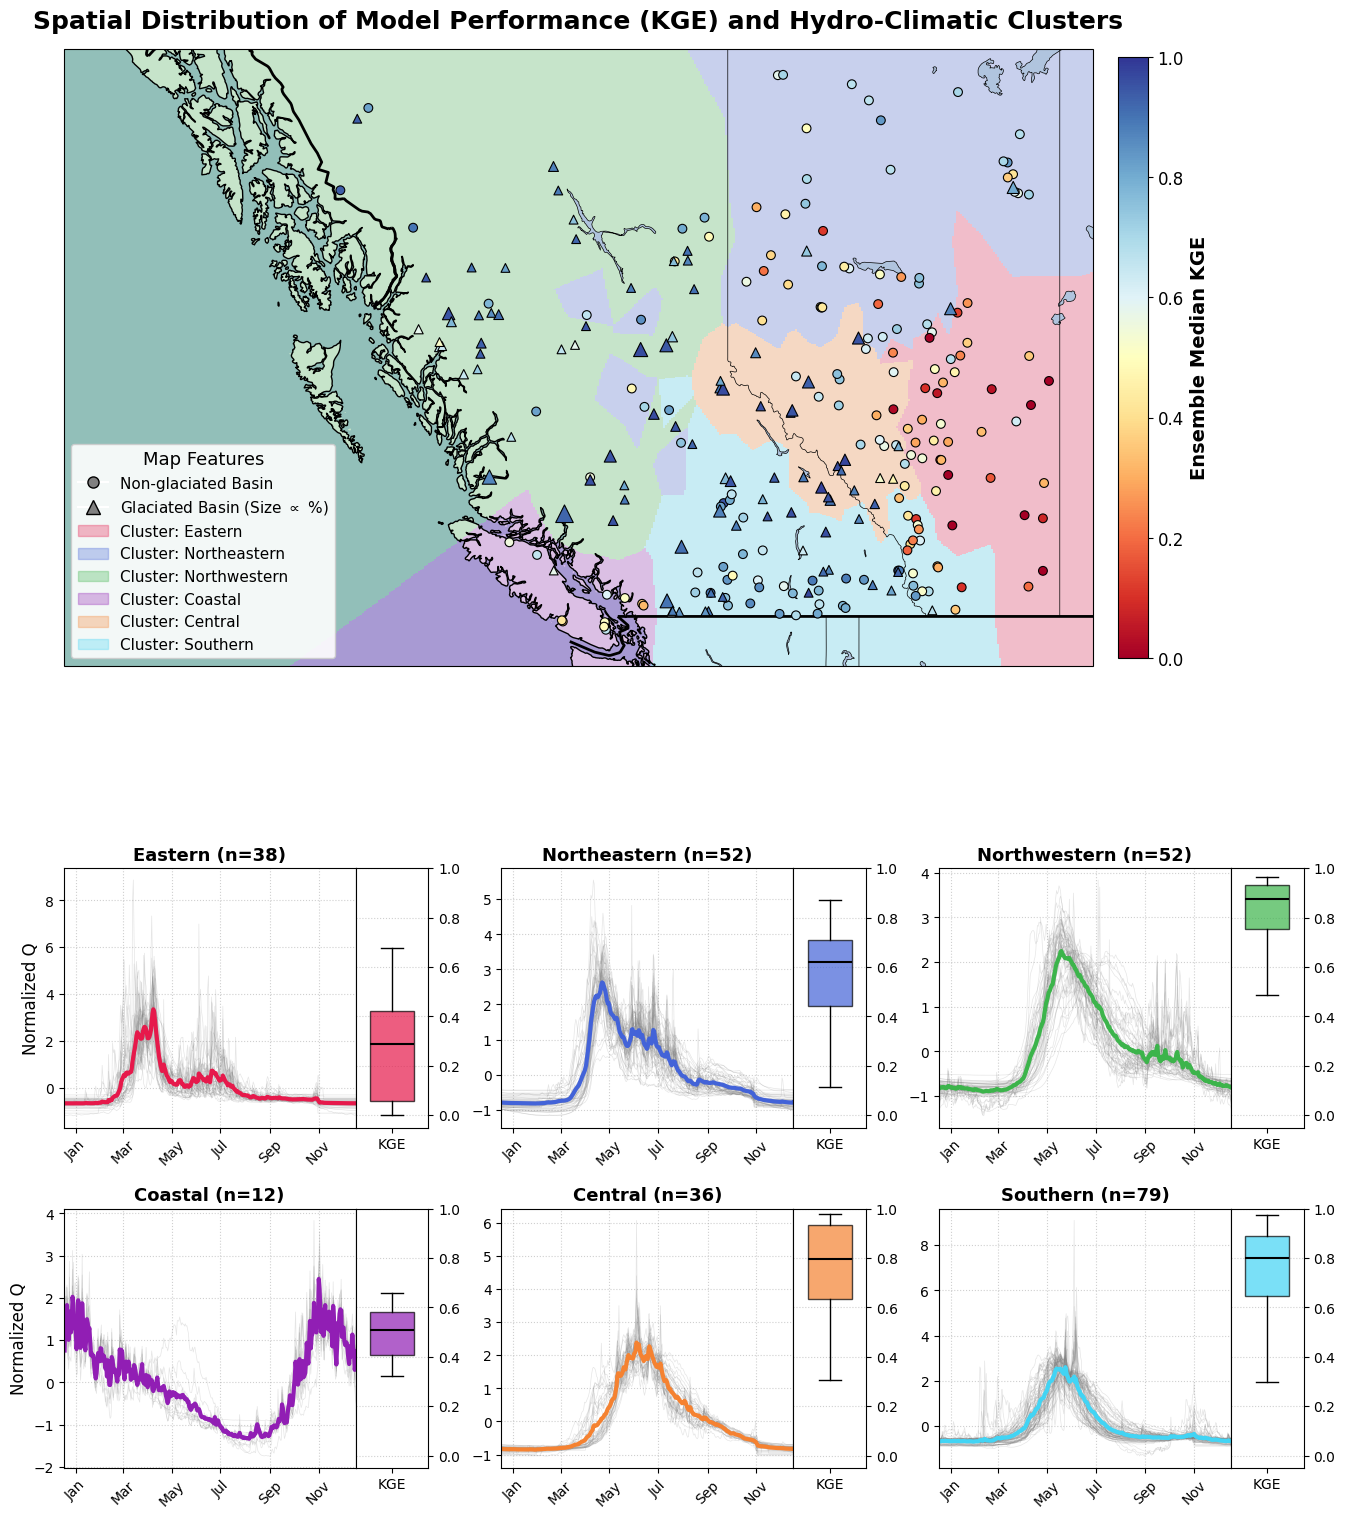

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np
import warnings
from src.config import TEST_START_YEAR, TEST_END_YEAR

warnings.filterwarnings('ignore')

# =========================================================
# 1. Temporal Filtering for KGE (Test Period Only)
# =========================================================
df_obs_test = df_obs[(df_obs.index.year >= TEST_START_YEAR) & (df_obs.index.year <= TEST_END_YEAR)]
df_pred_test = df_pred[(df_pred.index.year >= TEST_START_YEAR) & (df_pred.index.year <= TEST_END_YEAR)]

# =========================================================
# 2. Imputation for Hydrographs (Using ENTIRE Dataset)
# =========================================================
df_obs_imputed = df_obs.interpolate(method='linear', limit=7)
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).transform('mean'))
df_obs_imputed = df_obs_imputed.fillna(df_obs_imputed.min())

# =========================================================
# 3. Calculate KGE across Ensemble Mean (No Interpolation)
# =========================================================
print("Calculating KGE values on test set...")
all_stations = df_obs.columns
station_median_kge = {}

for stat in all_stations:
    if stat in df_pred_test.columns:
        obs_vals = df_obs_test[stat].values
        sim_vals = df_pred_test[stat].values
        stat_kge = kge(obs_vals, sim_vals)
        station_median_kge[stat] = np.clip(stat_kge, 0, 1)

df_kge = pd.DataFrame.from_dict(station_median_kge, orient='index', columns=['KGE'])
glacier_col = [c for c in df_attr.columns if 'glac' in c.lower()][0]

# =========================================================
# 4. Clustering (Using Hydrographs + Spatial Coordinates)
# =========================================================
print("Computing hydrographs and clustering...")
avg_hydrograph = df_obs_imputed.groupby(df_obs_imputed.index.dayofyear).mean()
avg_hydrograph_norm = (avg_hydrograph - avg_hydrograph.mean()) / avg_hydrograph.std()

X_hydro = avg_hydrograph_norm.T
X_merged = X_hydro.join(df_attr[['latitude', 'longitude']], how='inner')

hydro_features = X_merged.drop(columns=['latitude', 'longitude']).values
lat_norm = (X_merged['latitude'] - X_merged['latitude'].mean()) / X_merged['latitude'].std()
lon_norm = (X_merged['longitude'] - X_merged['longitude'].mean()) / X_merged['longitude'].std()

lat_features = np.tile(lat_norm.values, (182, 1)).T
lon_features = np.tile(lon_norm.values, (182, 1)).T

X_cluster_input = np.hstack((hydro_features, lat_features, lon_features))
Z = linkage(X_cluster_input, method='ward')
cluster_labels = fcluster(Z, t=6, criterion='maxclust') - 1

df_plot = pd.DataFrame({'Cluster': cluster_labels}, index=X_merged.index)
df_plot = df_plot.join(df_attr[['latitude', 'longitude', glacier_col]], how='inner')
df_plot = df_plot.rename(columns={glacier_col: 'glacier_pct'})
df_plot = df_plot.join(df_kge, how='inner')
df_plot['glacier_pct'] = df_plot['glacier_pct'].fillna(0)

cluster_names = {0: "Eastern", 1: "Northeastern", 2: "Northwestern", 3: "Coastal", 4: "Central", 5: "Southern"}
cluster_colors = ['#e6194B', '#4363d8', '#3cb44b', '#911eb4', '#f58231', '#42d4f4']
cmap_clusters = ListedColormap(cluster_colors)

# =========================================================
# 5. Generate Voronoi Grid (KNN Approach)
# =========================================================
print("Generating Voronoi spatial grid...")
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(df_plot[['longitude', 'latitude']], df_plot['Cluster'])

xx, yy = np.meshgrid(np.linspace(-140, -109, 500), np.linspace(48, 59, 500))
Z_grid = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_grid = Z_grid.reshape(xx.shape)

# =========================================================
# 6. Plotting - Master Layout
# =========================================================
print("Rendering final plot...")

# Pre-calculate global lower limit for KGE boxplots (ignoring outliers)
global_min_whisker = 1.0
for cid in range(6):
    kge_vals = df_plot.loc[df_plot['Cluster'] == cid, 'KGE'].dropna()
    if not kge_vals.empty:
        q1 = kge_vals.quantile(0.25)
        q3 = kge_vals.quantile(0.75)
        iqr = q3 - q1
        lower_whisker = max(kge_vals.min(), q1 - 1.5 * iqr)
        global_min_whisker = min(global_min_whisker, lower_whisker)
        
# y_lower_bound = max(0.0, global_min_whisker - 0.05) # Add 0.05 padding, floor at 0
y_lower_bound = global_min_whisker - 0.05

fig = plt.figure(figsize=(16, 20))
gs = fig.add_gridspec(4, 3, height_ratios=[1.5, 1.5, 1, 1], hspace=0.25, wspace=0.2)

# --- PANEL A: The Map ---
ax_map = fig.add_subplot(gs[0:2, :], projection=ccrs.Mercator())
ax_map.set_extent([-140, -109, 48, 59], crs=ccrs.PlateCarree())

res = '10m' 
ax_map.add_feature(cfeature.LAND.with_scale(res), facecolor='whitesmoke', zorder=0)
ax_map.add_feature(cfeature.OCEAN.with_scale(res), facecolor='lightsteelblue', zorder=0)
ax_map.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='black', zorder=2)
ax_map.add_feature(cfeature.LAKES.with_scale(res), facecolor='lightsteelblue', edgecolor='black', linewidth=0.5, zorder=2)

provinces = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale=res, facecolor='none')
ax_map.add_feature(provinces, edgecolor='black', linewidth=0.5, zorder=3)
ax_map.add_feature(cfeature.BORDERS.with_scale(res), linestyle='-', edgecolor='black', linewidth=2.0, zorder=3)

# Plot Voronoi Shading
ax_map.pcolormesh(xx, yy, Z_grid, cmap=cmap_clusters, alpha=0.25, transform=ccrs.PlateCarree(), zorder=1)

# Plot Heatmap Points (Non-glaciated)
sc_non_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] == 0]['longitude'], 
    df_plot[df_plot['glacier_pct'] == 0]['latitude'],
    c=df_plot[df_plot['glacier_pct'] == 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=40, marker='o', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=5
)

# Plot Heatmap Points (Glaciated) scaled dynamically 
max_glacier = df_plot['glacier_pct'].max() if df_plot['glacier_pct'].max() > 0 else 1
glac_sizes = 40 + (df_plot[df_plot['glacier_pct'] > 0]['glacier_pct'] / max_glacier) * 120

sc_glac = ax_map.scatter(
    df_plot[df_plot['glacier_pct'] > 0]['longitude'], 
    df_plot[df_plot['glacier_pct'] > 0]['latitude'],
    c=df_plot[df_plot['glacier_pct'] > 0]['KGE'],
    cmap='RdYlBu', vmin=0, vmax=1,
    s=glac_sizes, 
    marker='^', edgecolors='k', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=6
)

cbar = plt.colorbar(sc_non_glac, ax=ax_map, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Ensemble Median KGE', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Legend Configuration
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, markeredgecolor='k', label='Non-glaciated Basin'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, markeredgecolor='k', label='Glaciated Basin (Size $\propto$ %)')
]
for i in range(6):
    legend_elements.append(mpatches.Patch(color=cluster_colors[i], alpha=0.3, label=f'Cluster: {cluster_names[i]}'))

ax_map.legend(handles=legend_elements, loc='lower left', title="Map Features", fontsize=11, title_fontsize=13, framealpha=0.9)
ax_map.set_title('Spatial Distribution of Model Performance (KGE) and Hydro-Climatic Clusters', fontsize=18, fontweight='bold', pad=15)

# --- PANEL B: The Hydrographs and KGE Boxplots ---
month_ticks = [15, 74, 135, 196, 258, 319]
month_labels = ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov']

for cluster_id in range(6):
    row = 2 + (cluster_id // 3)
    col = cluster_id % 3
    
    inner_gs = gs[row, col].subgridspec(1, 2, width_ratios=[4, 1], wspace=0.0)
    
    ax_hydro = fig.add_subplot(inner_gs[0])
    ax_box = fig.add_subplot(inner_gs[1])
    
    station_names = df_plot[df_plot['Cluster'] == cluster_id].index
    cluster_hydro_data = avg_hydrograph_norm[station_names]
    cluster_kge = df_plot.loc[station_names, 'KGE'].dropna()
    
    # -- 1. Plot Hydrograph --
    ax_hydro.plot(cluster_hydro_data.index, cluster_hydro_data.values, color='gray', alpha=0.2, linewidth=0.5)
    cluster_mean = cluster_hydro_data.mean(axis=1)
    ax_hydro.plot(cluster_mean.index, cluster_mean.values, color=cluster_colors[cluster_id], linewidth=3)
    
    ax_hydro.set_title(f"{cluster_names[cluster_id]} (n={len(station_names)})", fontsize=13, fontweight='bold')
    ax_hydro.set_xticks(month_ticks)
    ax_hydro.set_xticklabels(month_labels, rotation=45)
    ax_hydro.set_xlim(0, 365)
    ax_hydro.grid(True, linestyle=':', alpha=0.6)
    
    if col == 0:
        ax_hydro.set_ylabel('Normalized Q', fontsize=12)
        
    # -- 2. Plot Boxplot --
    box = ax_box.boxplot(cluster_kge, showfliers=False, widths=0.6, patch_artist=True)
    
    for patch in box['boxes']:
        patch.set_facecolor(cluster_colors[cluster_id])
        patch.set_alpha(0.7)
    for median in box['medians']:
        median.set(color='black', linewidth=1.5)
        
    # Apply calculated dynamic minimum bound
    ax_box.set_ylim(y_lower_bound, 1)
    ax_box.set_xticks([1])
    ax_box.set_xticklabels(['KGE'], fontsize=10)
    
    # Shift numerical ticks to the right side
    ax_box.yaxis.tick_right()
    ax_box.grid(True, axis='y', linestyle=':', alpha=0.6)
    ax_box.tick_params(axis='y', labelsize=10)

plt.show()

Counterfactual performance demonstration

Extracting data for Station 05DA009...
Calculating DL ensemble predictions and uncertainties...
Generating plots...


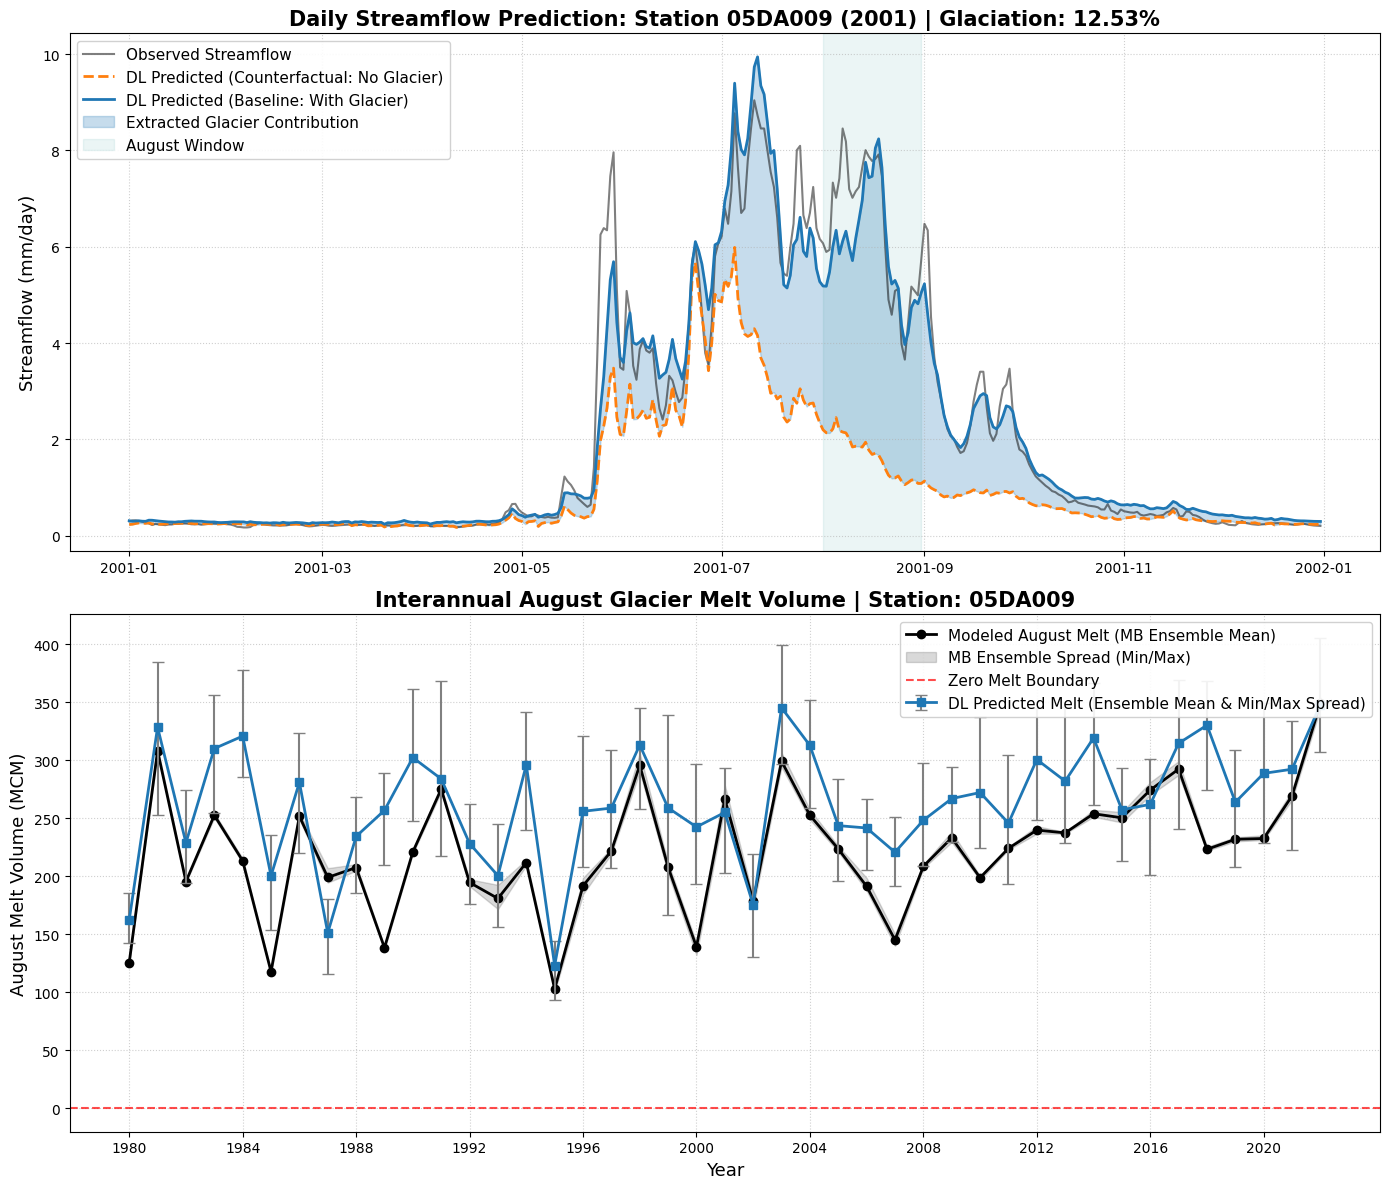

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# =========================================================
# 1. USER INPUTS
# =========================================================
TARGET_STATION = '05DA009'  # Change to explore different stations
TARGET_YEAR = 2001          # Change to explore different years

# =========================================================
# 2. Extract Target Data from Pre-loaded Environment
# =========================================================
print(f"Extracting data for Station {TARGET_STATION}...")

basin_area = df_attr.loc[TARGET_STATION, 'basin_area_km2']
glac_pct = df_attr.loc[TARGET_STATION, 'glacier_pct']

# Observations are already in mm/day per the environment template
obs_series = df_obs[TARGET_STATION]

# Extract and process the 3-member Mass Balance Ensemble
list_mb_aug_yearly = []
for mb_member in df_mbs:
    # Extract August data, and multiply by -1 to flip sign from mass loss to positive melt
    mb_aug = -mb_member[TARGET_STATION][mb_member.index.month == 8]
    mb_aug_sum = mb_aug.groupby(mb_aug.index.year).sum()
    list_mb_aug_yearly.append(mb_aug_sum)

# Aggregate MB ensemble
df_act_aug_yearly = pd.concat(list_mb_aug_yearly, axis=1)
act_aug_mcm_mean = df_act_aug_yearly.mean(axis=1)

# =========================================================
# 3. Process DL Ensemble Predictions and Uncertainty Spread
# =========================================================
print("Calculating DL ensemble predictions and uncertainties...")

list_aug_mcm_yearly = []

# Iterate through the pre-loaded lists of DL ensemble DataFrames
for pred_member, cf_member in zip(df_preds, df_cf_preds):
    pred = pred_member[TARGET_STATION]
    noglac = cf_member[TARGET_STATION]
    
    # Calculate yearly August MCM for this specific ensemble member
    diff_mm = pred - noglac
    aug_diff_mm = diff_mm[diff_mm.index.month == 8].groupby(diff_mm[diff_mm.index.month == 8].index.year).sum()
    
    # Convert mm over the basin to Million Cubic Meters (MCM)
    aug_mcm = aug_diff_mm * basin_area * 0.001
    list_aug_mcm_yearly.append(aug_mcm)

# Aggregate yearly August melt across the DL ensemble
df_aug_yearly = pd.concat(list_aug_mcm_yearly, axis=1)

# Extract deterministic daily means directly from the pre-computed templates
mean_pred_daily = df_pred[TARGET_STATION]
mean_noglac_daily = df_cf_pred[TARGET_STATION]

# --- Alignment and Uncertainty Calculations ---

# Ensure years align perfectly between DL predictions and MB ground truth
common_years = df_aug_yearly.index.intersection(act_aug_mcm_mean.index)

# 1. Subset DL predictions and calculate bounds
df_aug_yearly = df_aug_yearly.loc[common_years]
mean_aug_mcm = df_aug_yearly.mean(axis=1)
min_aug_mcm = df_aug_yearly.min(axis=1)
max_aug_mcm = df_aug_yearly.max(axis=1)

err_lower = mean_aug_mcm - min_aug_mcm
err_upper = max_aug_mcm - mean_aug_mcm
dl_yerr = [err_lower.values, err_upper.values]

# 2. Subset MB predictions and calculate bounds
df_act_aug_yearly = df_act_aug_yearly.loc[common_years]
act_aug_mcm_mean = act_aug_mcm_mean.loc[common_years]
act_min_aug_mcm = df_act_aug_yearly.min(axis=1)
act_max_aug_mcm = df_act_aug_yearly.max(axis=1)

# =========================================================
# 4. Plotting
# =========================================================
print("Generating plots...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1, 1]})

# ---------------------------------------------------------
# PANEL 1: Daily Hydrograph with Shaded Glacier Contribution
# ---------------------------------------------------------
year_mask = mean_pred_daily.index.year == TARGET_YEAR
dates_yr = mean_pred_daily[year_mask].index

pred_yr = mean_pred_daily[year_mask]
noglac_yr = mean_noglac_daily[year_mask]
obs_yr = obs_series[year_mask]

ax1.plot(dates_yr, obs_yr, color='black', alpha=0.5, label='Observed Streamflow', linewidth=1.5)
ax1.plot(dates_yr, noglac_yr, color='tab:orange', linestyle='--', label='DL Predicted (Counterfactual: No Glacier)', linewidth=2)
ax1.plot(dates_yr, pred_yr, color='tab:blue', label='DL Predicted (Baseline: With Glacier)', linewidth=2)

# Shade the area ONLY where With Glacier > Without Glacier
ax1.fill_between(dates_yr, noglac_yr, pred_yr, where=(pred_yr > noglac_yr), 
                 interpolate=True, color='tab:blue', alpha=0.25, label='Extracted Glacier Contribution')

# Highlight August Window
aug_start = pd.to_datetime(f"{TARGET_YEAR}-08-01")
aug_end = pd.to_datetime(f"{TARGET_YEAR}-08-31")
ax1.axvspan(aug_start, aug_end, color='teal', alpha=0.08, label='August Window')

ax1.set_title(f"Daily Streamflow Prediction: Station {TARGET_STATION} ({TARGET_YEAR}) | Glaciation: {glac_pct:.2f}%", fontsize=15, fontweight='bold')
ax1.set_ylabel("Streamflow (mm/day)", fontsize=13)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)

# ---------------------------------------------------------
# PANEL 2: Interannual August Melt Time Series w/ Bounds
# ---------------------------------------------------------
years = common_years.values

# Plot the Actual Mass Balance (Ground Truth) with Shaded Uncertainty
ax2.plot(years, act_aug_mcm_mean.values, color='black', marker='o', linestyle='-', linewidth=2, markersize=6, label='Modeled August Melt (MB Ensemble Mean)')
ax2.fill_between(years, act_min_aug_mcm.values, act_max_aug_mcm.values, color='black', alpha=0.15, label='MB Ensemble Spread (Min/Max)')

# Plot the DL Predicted Mean with Ensemble Error Bars
ax2.errorbar(years, mean_aug_mcm.values, yerr=dl_yerr, fmt='s-', color='tab:blue', linewidth=2, capsize=4, 
             ecolor='gray', elinewidth=1.5, markersize=6, label='DL Predicted Melt (Ensemble Mean & Min/Max Spread)')

ax2.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Melt Boundary')

ax2.set_title(f"Interannual August Glacier Melt Volume | Station: {TARGET_STATION}", fontsize=15, fontweight='bold')
ax2.set_ylabel("August Melt Volume (MCM)", fontsize=13)
ax2.set_xlabel("Year", fontsize=13)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Fix x-axis ticks to show round years cleanly
ax2.set_xticks(np.arange(min(years), max(years)+1, 4))

plt.tight_layout()
plt.show()

SOM cluster patterns

Correlations and evaluation metrics

Supplementary: histogram of static attributes